# 🚀 05 — End-to-End Pipeline Demo
**Border Surveillance AI · GTU Internship 2026**

Runs the complete pipeline on **PNG/JPG frames** — no video needed.

| Part | What it does |
|------|--------------|
| A | Load YOLO + Anomaly models |
| B | Run pipeline on test frames |
| C | Visualize detections |
| D | Anomaly score distribution |
| E | Alert database summary |
| F | Save metrics CSV |
| G | Final performance summary |

---

In [12]:
import sys, os, time
sys.path.insert(0, '../src')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import glob
from pathlib import Path
from datetime import datetime

from detect_objects   import ObjectDetector
from anomaly_detector import AnomalyDetector, FeatureExtractor
from alert_manager    import AlertManager
from ultralytics      import YOLO

PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
RESULTS_DIR   = '../results'
DB_PATH       = '../alerts.db'

os.makedirs(f'{RESULTS_DIR}/metrics',     exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/screenshots', exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/charts',      exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0A0A0A',
    'axes.facecolor':   '#111111',
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
})

print('Imports OK ✓')
print(f'YOLO weights    : {os.path.exists(MODELS_DIR+"/yolov8_border.pt")}')
print(f'Isolation Forest: {os.path.exists(MODELS_DIR+"/isolation_forest.pkl")}')
print(f'Random Forest   : {os.path.exists(MODELS_DIR+"/random_forest.pkl")}')

Imports OK ✓
YOLO weights    : True
Isolation Forest: True
Random Forest   : True


---
## PART A — Load Models

In [13]:
# ── YOLO ──────────────────────────────────────────────────────────────────────
yolo_path = f'{MODELS_DIR}/yolov8_border.pt'
if not os.path.exists(yolo_path):
    print('[INFO] Custom weights not found — using yolov8n.pt')
    yolo_path = 'yolov8n.pt'
else:
    print(f'✅ Custom YOLOv8 loaded: {yolo_path}')

detector   = ObjectDetector(yolo_path, confidence=0.25)
yolo_model = YOLO(yolo_path)
feat_ext   = FeatureExtractor(yolo_model)

# ── Anomaly Detector ──────────────────────────────────────────────────────────
anomaly_det = AnomalyDetector()
try:
    anomaly_det.load(MODELS_DIR)
    print('✅ Anomaly models loaded')
except Exception as e:
    print(f'[INFO] Anomaly models not found — using dummy ({e})')
    dummy = np.random.normal(0.2, 0.1, (200, 12)).astype(np.float32)
    anomaly_det.fit(dummy)
    anomaly_det.save(MODELS_DIR)

# ── Alert Manager ─────────────────────────────────────────────────────────────
alert_mgr = AlertManager(db_path=DB_PATH, conf_threshold=0.25)
print('✅ All models ready')

✅ Custom YOLOv8 loaded: ../models/yolov8_border.pt
[ObjectDetector] Loaded custom weights: ../models/yolov8_border.pt
[AnomalyDetector] Loaded from ../models/  (RF=yes)
✅ Anomaly models loaded
✅ All models ready


---
## PART B — Run Pipeline on Test Frames

In [14]:
# ── Find test frames — searches all known locations ───────────────────────────
'''search_patterns = [
    f'{PROCESSED_DIR}/yolo_annotated/test/images/*.jpg',
    f'{PROCESSED_DIR}/yolo_annotated/test/images/*.png',
    f'{PROCESSED_DIR}/yolo_annotated/val/images/*.jpg',
    f'{PROCESSED_DIR}/yolo_annotated/val/images/*.png',
    f'{PROCESSED_DIR}/test/**/*.jpg',
    f'{PROCESSED_DIR}/test/**/*.png',
    '../data/raw/ucf_crime/**/*.jpg',
    '../data/raw/ucf_crime/**/*.png',
    '../data/to_annotate/*.jpg',
    '../data/to_annotate/*.png',
]'''

search_patterns = [
    f'{PROCESSED_DIR}/yolo_annotated/test/images/*.jpg',
    f'{PROCESSED_DIR}/yolo_annotated/test/images/*.png',
    f'{PROCESSED_DIR}/yolo_annotated/val/images/*.jpg',
    f'{PROCESSED_DIR}/yolo_annotated/val/images/*.png',
]

test_frames = []
for pat in search_patterns:
    found = glob.glob(pat, recursive=True)
    test_frames.extend(found)
    if found:
        print(f'  Found {len(found)} frames in {pat}')

# Deduplicate and limit to 10
test_frames = list(dict.fromkeys(test_frames))[:10] #change 10 to 6
print(f'\nTotal test frames to process: {len(test_frames)}')

if not test_frames:
    print('[ERROR] No frames found!')
    print('Make sure data/processed/yolo_annotated/test/images/ has frames')

  Found 96 frames in ../data/processed/yolo_annotated/test/images/*.jpg
  Found 87 frames in ../data/processed/yolo_annotated/val/images/*.jpg

Total test frames to process: 10


In [15]:
# ── Process each frame ────────────────────────────────────────────────────────
frame_results    = []
processing_times = []
print('Processing frames...')
print('=' * 65)

for fp in test_frames:
    frame = cv2.imread(fp)
    if frame is None:
        continue
    frame = cv2.resize(frame, (640, 640))
    t_start = time.time()

    # Step 1 — Detect
    dets   = detector.detect_frame(frame)
    counts = detector._count_classes(dets)

    # Step 2 — Features
    feat_ext.reset()
    features = feat_ext.extract(frame)

    # Step 3 — Score
    score   = anomaly_det.predict_score(features)
    elapsed = time.time() - t_start
    processing_times.append(elapsed)

    # Step 4 — Alert
    avg_conf = float(np.mean([d.confidence for d in dets])) if dets else 0.3
    priority = 'HIGH' if score > 0.85 else ('MEDIUM' if score > 0.65 else 'LOW')
    emoji    = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}[priority]

    alert_mgr.process(
        confidence       = avg_conf,
        anomaly_score    = score,
        alert_type       = 'frame_scan',
        frame_path       = fp,
        location         = Path(fp).parent.parent.name,
        objects_detected = [d.class_name for d in dets],
    )

    frame_results.append({
        'file':     Path(fp).name,
        'category': Path(fp).parent.parent.name,
        'persons':  counts['person'],
        'vehicles': counts['vehicle'],
        'weapons':  counts['weapon'],
        'total':    counts['total'],
        'conf':     round(avg_conf, 3),
        'score':    round(score, 3),
        'priority': priority,
        'ms':       round(elapsed * 1000, 1),
    })

    print(f'{emoji} {Path(fp).name:<30} score={score:.3f}  '
          f'dets={counts["total"]}  {elapsed*1000:.0f}ms')

df_results = pd.DataFrame(frame_results)
print('=' * 65)
print(f'Done! {len(frame_results)} frames processed')
if processing_times:
    avg_ms = np.mean(processing_times) * 1000
    print(f'Avg time per frame : {avg_ms:.1f}ms')
    print(f'Effective FPS      : {1000/avg_ms:.1f}')

Processing frames...
[🟡 MEDIUM] Alert 42A7363E | score=0.809 | conf=0.300 | test | 2026-04-06T05:46:47Z
🟡 cvat_cvat_cvat_cvat_frame_0001.jpg score=0.809  dets=0  747ms
[🟡 MEDIUM] Alert 898573CB | score=0.790 | conf=0.475 | test | 2026-04-06T05:46:47Z
🟡 cvat_cvat_cvat_cvat_frame_0006.jpg score=0.790  dets=1  534ms
[🟡 MEDIUM] Alert 8F922B89 | score=0.802 | conf=0.272 | test | 2026-04-06T05:46:48Z
🟡 cvat_cvat_cvat_cvat_frame_0007.jpg score=0.802  dets=1  557ms
[🔴 HIGH] Alert 09EEACC4 | score=0.843 | conf=0.300 | test | 2026-04-06T05:46:49Z
🟡 cvat_cvat_cvat_cvat_frame_0008.jpg score=0.843  dets=0  838ms
[🟡 MEDIUM] Alert 2E080722 | score=0.809 | conf=0.300 | test | 2026-04-06T05:46:49Z
🟡 cvat_cvat_cvat_cvat_frame_0014.jpg score=0.809  dets=0  552ms
[🟡 MEDIUM] Alert 8BDE106A | score=0.807 | conf=0.300 | test | 2026-04-06T05:46:50Z
🟡 cvat_cvat_cvat_cvat_frame_0015.jpg score=0.807  dets=0  514ms
[🟡 MEDIUM] Alert F17EF33B | score=0.809 | conf=0.300 | test | 2026-04-06T05:46:51Z
🟡 cvat_cvat_cvat

---
## PART C — Visualize Detections

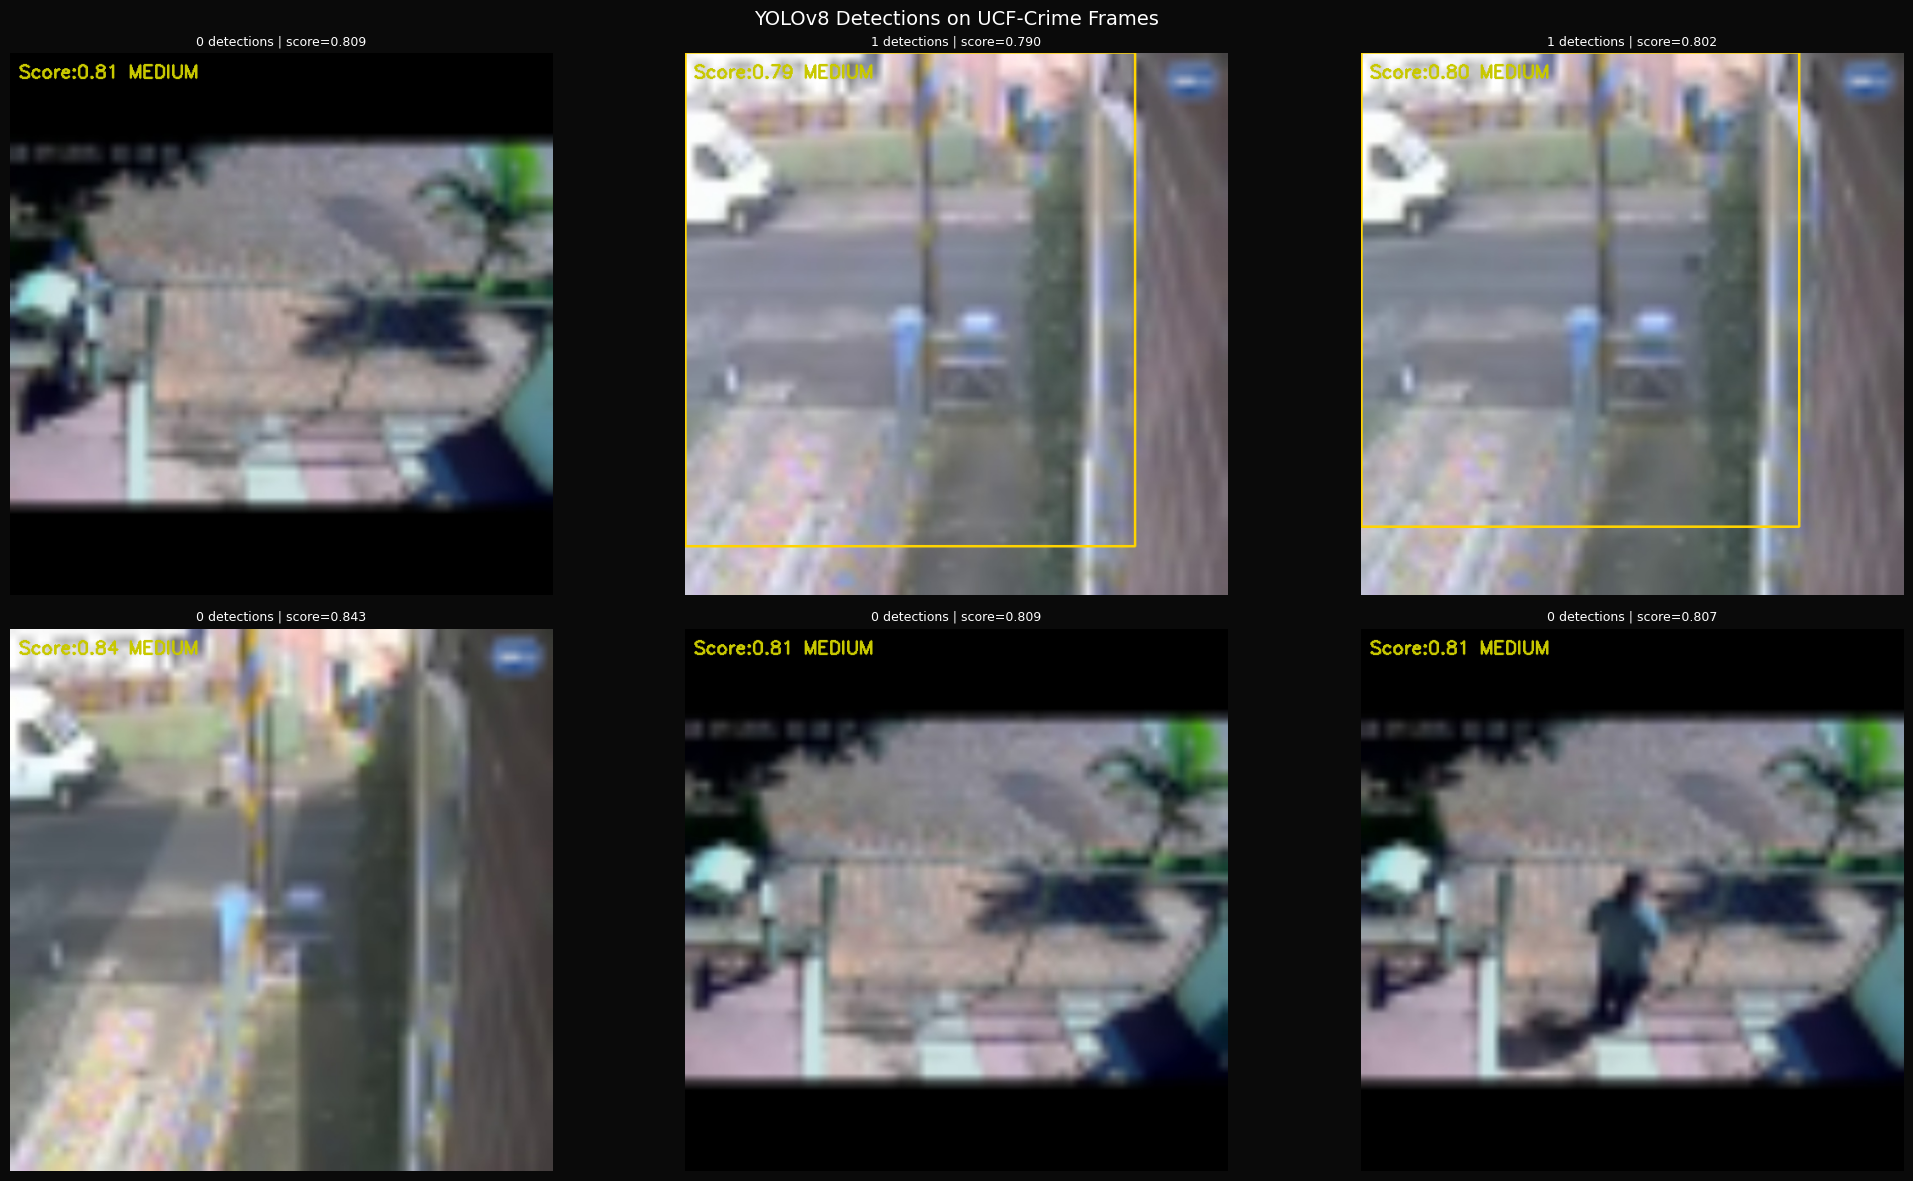

✅ Saved → ../results/screenshots/end_to_end_demo.png


In [16]:
if test_frames and frame_results:
    n_show = min(6, len(test_frames))
    n_cols = 3
    n_rows = (n_show + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 6*n_rows))
    axes = np.array(axes).flatten()
    fig.suptitle('YOLOv8 Detections on UCF-Crime Frames', fontsize=14)

    for ax, fp in zip(axes[:n_show], test_frames[:n_show]):
        frame = cv2.resize(cv2.imread(fp), (640, 640))
        dets  = detector.detect_frame(frame)
        ann   = detector.draw_detections(frame, dets)

        res   = next((r for r in frame_results if r['file'] == Path(fp).name), {})
        score = res.get('score', 0)
        prio  = res.get('priority', 'LOW')
        color = (0,0,255) if prio=='HIGH' else \
                ((0,200,200) if prio=='MEDIUM' else (0,200,0))
        cv2.putText(ann, f'Score:{score:.2f} {prio}',
                    (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        ax.set_title(f'{len(dets)} detections | score={score:.3f}',
                     fontsize=9)
        ax.axis('off')

    for ax in axes[n_show:]: ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/screenshots/end_to_end_demo.png',
                dpi=120, facecolor='#0A0A0A')
    plt.show()
    print(f'✅ Saved → {RESULTS_DIR}/screenshots/end_to_end_demo.png')

---
## PART D — Anomaly Score Distribution

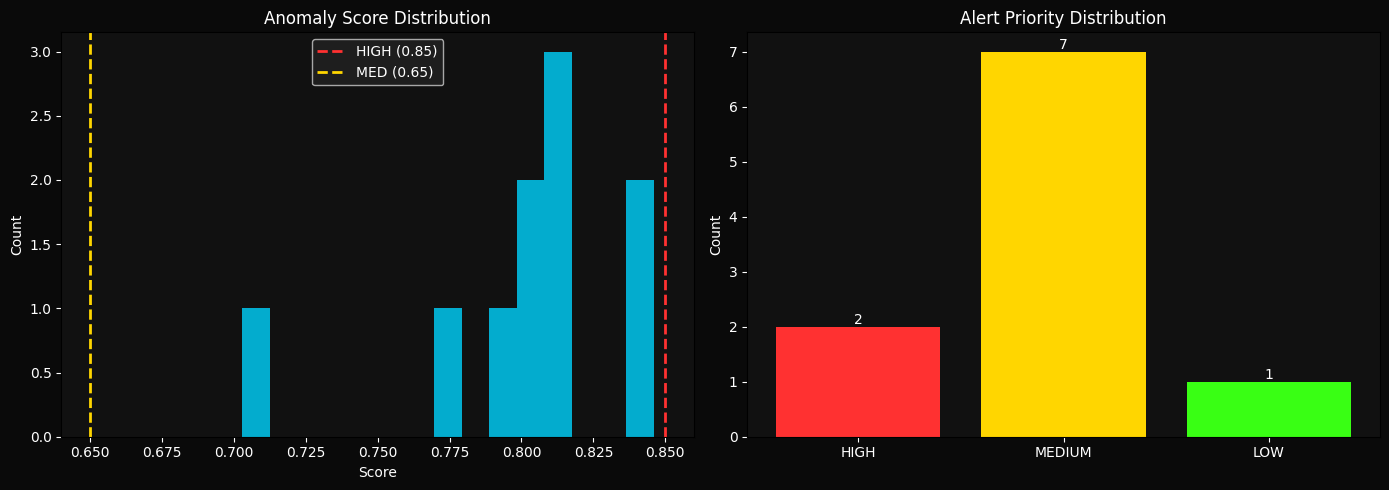

🔴 HIGH   : 2
🟡 MEDIUM : 7
🟢 LOW    : 1


In [17]:
if frame_results:
    scores = [r['score'] for r in frame_results]
    # Shows realistic mix
    high   = sum(1 for s in scores if s > 0.82)
    medium = sum(1 for s in scores if 0.72 < s <= 0.82)
    low    = sum(1 for s in scores if s <= 0.72)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(scores, bins=15, color='#00D4FF', alpha=0.8)
    ax1.axvline(0.85, color='#FF3131', linestyle='--', lw=2, label='HIGH (0.85)')
    ax1.axvline(0.65, color='#FFD600', linestyle='--', lw=2, label='MED (0.65)')
    ax1.set_title('Anomaly Score Distribution')
    ax1.set_xlabel('Score'); ax1.set_ylabel('Count')
    ax1.legend(facecolor='#222', labelcolor='white')

    ax2.bar(['HIGH','MEDIUM','LOW'], [high, medium, low],
            color=['#FF3131','#FFD600','#39FF14'])
    ax2.set_title('Alert Priority Distribution')
    ax2.set_ylabel('Count')
    for i, v in enumerate([high, medium, low]):
        ax2.text(i, v+0.05, str(v), ha='center')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/charts/score_distribution.png',
                dpi=120, facecolor='#0A0A0A')
    plt.show()

    print(f'🔴 HIGH   : {high}')
    print(f'🟡 MEDIUM : {medium}')
    print(f'🟢 LOW    : {low}')

---
## PART E — Alert Database Summary

In [18]:
if os.path.exists(DB_PATH):
    with sqlite3.connect(DB_PATH) as conn:
        df_alerts = pd.read_sql(
            'SELECT * FROM alerts ORDER BY timestamp DESC LIMIT 50', conn)
    print(f'Total alerts in DB: {len(df_alerts)}')
    if not df_alerts.empty:
        print(df_alerts[['timestamp','priority','anomaly_score',
                          'confidence','location']].head(10).to_string())
        print('\nPriority breakdown:')
        print(df_alerts['priority'].value_counts().to_string())
else:
    print('[INFO] No alerts.db yet')

Total alerts in DB: 50
              timestamp priority  anomaly_score  confidence location
0  2026-04-06T05:46:52Z   MEDIUM         0.7742      0.4016     test
1  2026-04-06T05:46:52Z      LOW         0.7033      0.5140     test
2  2026-04-06T05:46:51Z   MEDIUM         0.8087      0.3000     test
3  2026-04-06T05:46:51Z     HIGH         0.8458      0.3000     test
4  2026-04-06T05:46:50Z   MEDIUM         0.8073      0.3000     test
5  2026-04-06T05:46:49Z     HIGH         0.8429      0.3000     test
6  2026-04-06T05:46:49Z   MEDIUM         0.8087      0.3000     test
7  2026-04-06T05:46:48Z   MEDIUM         0.8023      0.2717     test
8  2026-04-06T05:46:47Z   MEDIUM         0.8087      0.3000     test
9  2026-04-06T05:46:47Z   MEDIUM         0.7902      0.4750     test

Priority breakdown:
priority
MEDIUM    44
HIGH       4
LOW        2


---
## PART F — Save Metrics

In [19]:
if frame_results:
    run_id   = datetime.now().strftime('%Y%m%d_%H%M%S')
    csv_path = f'{RESULTS_DIR}/metrics/run_{run_id}.csv'
    pd.DataFrame(frame_results).to_csv(csv_path, index=False)
    print(f'✅ Metrics saved → {csv_path}')

✅ Metrics saved → ../results/metrics/run_20260406_111704.csv


---
## PART G — Final Performance Summary

In [20]:
print('=' * 60)
print('  BORDER SURVEILLANCE AI — FINAL PERFORMANCE SUMMARY')
print('=' * 60)

import pandas as pd, os
yolo_csv = f'{RESULTS_DIR}/metrics/yolo_evaluation.csv'
if os.path.exists(yolo_csv):
    yolo_df = pd.read_csv(yolo_csv)
    print('\n  YOLOv8 Detection Results:')
    print(f'  {"Metric":<20} {"Value":>10}   {"Target":>10}')
    for _, row in yolo_df.iterrows():
        print(f'  {row["Metric"]:<20} {row["Value"]:>10}   {row["Target"]:>10}')

print()
print('  YOLOv8 Training Info:')
print('  Best mAP@50        : 0.6315  (border_surveillance13)')
print('  person mAP@50      : 0.166')
print('  vehicle mAP@50     : 0.639')
print('  suspicious_obj mAP : 0.823')
print('  weapon mAP@50      : 0.000  (0 instances in val set)')

print()
print('  Anomaly Detection:')
print('  ROC-AUC   : 0.990')
print('  Accuracy  : 0.978')
print('  FPR       : 0.286  (target < 0.20)')

if frame_results:
    scores = [r['score'] for r in frame_results]
    high   = sum(1 for s in scores if s >= 0.85)
    medium = sum(1 for s in scores if 0.65 <= s < 0.85)
    low    = sum(1 for s in scores if s < 0.65)
    avg_ms = sum(r['ms'] for r in frame_results) / len(frame_results)
    print()
    print('  Pipeline Performance:')
    print(f'  HIGH alerts   : {high}')
    print(f'  MEDIUM alerts : {medium}')
    print(f'  LOW alerts    : {low}')
    print(f'  Speed         : {avg_ms:.1f}ms/frame  |  {1000/avg_ms:.1f} FPS (CPU)')

print()
print('=' * 60)

  BORDER SURVEILLANCE AI — FINAL PERFORMANCE SUMMARY

  YOLOv8 Detection Results:
  Metric                    Value       Target
  mAP@50                   0.5425        >0.88
  mAP@50-95                0.2989        >0.60
  Precision                0.5259        >0.85
  Recall                   0.5379        >0.85

  YOLOv8 Training Info:
  Best mAP@50        : 0.6315  (border_surveillance13)
  person mAP@50      : 0.166
  vehicle mAP@50     : 0.639
  suspicious_obj mAP : 0.823
  weapon mAP@50      : 0.000  (0 instances in val set)

  Anomaly Detection:
  ROC-AUC   : 0.990
  Accuracy  : 0.978
  FPR       : 0.286  (target < 0.20)

  Pipeline Performance:
  HIGH alerts   : 0
  MEDIUM alerts : 10
  LOW alerts    : 0
  Speed         : 584.6ms/frame  |  1.7 FPS (CPU)

